# Membership Functions for the PLGA Microparticle Release Dataset
### From the collaborator's crisp decision-tree rules → fuzzy Low / Medium / High memberships
**دوال العضوية الضبابية — من قواعد شجرة القرار الحادّة إلى قواعد ضبابية**

---

## Task 0 — What this notebook does, and why leakage control is the whole point

**In one paragraph.** A collaborator fitted a small decision tree
(`max_depth=3`) on four features — `Time`, `Polymer MW`, `Particle Size`, `LA/GA` —
and printed 8 rules (8 leaves). Those rules are **crisp**: a formulation either
satisfies `Time <= 3.34` or it does not, with nothing in between. This notebook takes
those 8 rules as the starting point and replaces every hard threshold with a **fuzzy
membership**: instead of "Time is short (yes/no)", we say "Time is Low with degree
0.8, Medium with degree 0.2, High with degree 0.0". That is the deliverable: the
membership functions and their plots.

**الفكرة باختصار:** بدل أن نقول «الزمن أقل من ٣٫٣٤ → نعم/لا»، نقول «الزمن منخفض بدرجة
٠٫٨، متوسط بدرجة ٠٫٢، مرتفع بدرجة ٠٫٠». هذا هو التحويل من الحادّ إلى الضبابي.

### Why leakage control is the top priority here

A membership function is **fitted from data** — its knots are quantiles of the
training values. That makes it exactly the same kind of object as a scaler: if you
compute it on the whole dataset, information from the rows you will later evaluate on
has already leaked into the model's inputs. Any score you report afterwards is
optimistic and not reproducible on new drugs.

So this notebook obeys four hard rules, and Task 6 proves each of them:

| # | Rule | Where it is enforced |
|---|------|----------------------|
| 1 | Split **first**, by drug (`Drug SMILES`), before computing anything | Task 3 |
| 2 | Knots come from the **training fold only**, applied unchanged to validation | Task 4 |
| 3 | Knots come from **per-formulation** values, not per-measurement | Task 4 |
| 4 | No clipping, no imputation, no monotonicity forcing, SMILES never a feature | Tasks 1, 6 |

### What we are deliberately fixing from the collaborator's notebook

The collaborator's notebook (`archive/Data-Preprocessing/datapreprocessing.ipynb`) is a good exploratory
pass, but it has four issues we must **not** carry forward:

1. **Leakage — scaler and tree fitted on the entire dataset.** `RobustScaler`,
   `MinMaxScaler` and `DecisionTreeRegressor` were all `.fit()` on all 4,913 rows with
   no train/test split at all. → *Fix:* we split **first** (Task 3), and every
   statistic after that point is a train-fold statistic.
2. **No drug grouping.** Even with a random split, rows of the *same drug* would land
   on both sides — and rows of the same drug are near-duplicates, so the model would
   effectively be tested on its own training data. → *Fix:* `GroupKFold` on exact
   `Drug SMILES`, with a printed proof of zero drug overlap across validation folds
   (Task 3).
3. **`Release.clip(0, 1)`.** The audit established that the 108 rows with
   `Release > 1` may be **real measurements** (cumulative release assays routinely
   exceed 100% through assay/normalisation error, and discarding them silently
   deletes evidence). → *Fix:* we keep the raw `Release` untouched, and Task 6 prints
   the actual max to prove it was never clipped.
4. **Rules are crisp, not fuzzy.** `Time <= 3.34` is a knife edge: two measurements
   0.01 h apart get completely different predictions. → *Fix:* that is precisely what
   Tasks 4–5 convert.

> ⚠️ **Unresolved assumption — the unit of `Time`.** The collaborator's plots label the axis
> "Time (Hours)", but the column ranges from 0 to 237.7 with a median of 8.0, which is
> equally consistent with **days**. This is **not resolved** and we do not resolve it
> here. It does not affect any membership function (quantiles are unit-free), but it
> **does** affect how any rule is worded in a paper. This warning is repeated at every
> point where `Time` is used.

---
## Task 1 — Load the data and attach `Drug SMILES` (the grouping key)

Two files:

* `mp_dataset_processed.xlsx` — the numeric features + `Time` + `Release`. This is what
  we model on.
* `mp_dataset_initial.xlsx` (sheet `PLGA_MPs`) — the same rows, but it still carries
  `Drug` and `Drug SMILES`. We need `Drug SMILES` **only as a grouping key** for the
  split. It is never a model input.

We attach SMILES **per `Formulation Index`** rather than by row position, so the merge
does not depend on the two files being in the same order. We also fix the known header
typo `Encapuslation` → `Encapsulation` in the initial file if it is present.

**التحميل:** نقرأ الملفين، ونربط رمز الدواء (SMILES) بكل صف عن طريق رقم التركيبة. رمز
الدواء يُستخدم فقط لتقسيم البيانات، ولا يدخل في النموذج أبداً.

Expected: **4,913 rows, 321 formulations, 88 unique SMILES.**

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeRegressor, export_text

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

PROCESSED_PATH = "mp_dataset_processed.xlsx"
INITIAL_PATH = "mp_dataset_initial.xlsx"

# --- load ------------------------------------------------------------------
proc = pd.read_excel(PROCESSED_PATH)
init = pd.read_excel(INITIAL_PATH, sheet_name="PLGA_MPs")

# fix the known header typo if it is there / تصحيح خطأ إملائي في اسم العمود
if "Drug Encapuslation Efficiency" in init.columns:
    init = init.rename(columns={"Drug Encapuslation Efficiency": "Drug Encapsulation Efficiency"})
    print("Renamed 'Drug Encapuslation Efficiency' -> 'Drug Encapsulation Efficiency'")

print("processed shape:", proc.shape)
print("initial   shape:", init.shape)

# --- SMILES is constant within a formulation: verify, then map -------------
per_form_smiles = init.groupby("Formulation Index")["Drug SMILES"].nunique()
assert (per_form_smiles == 1).all(), "A Formulation Index maps to >1 SMILES - merge key is unsafe"
smiles_map = init.groupby("Formulation Index")["Drug SMILES"].first()
drug_map = init.groupby("Formulation Index")["Drug"].first()

df = proc.copy()
n_before = len(df)
df["Drug SMILES"] = df["Formulation Index"].map(smiles_map)
df["Drug"] = df["Formulation Index"].map(drug_map)

assert len(df) == n_before, "Merge changed the row count"
assert df["Drug SMILES"].notna().all(), "Some rows have no SMILES"

# stable ordering, same as the collaborator's / نفس ترتيب المتعاون
df = df.sort_values(["Formulation Index", "Time"]).reset_index(drop=True)

# --- report ---------------------------------------------------------------
N_ROWS, N_FORMS, N_SMILES = len(df), df["Formulation Index"].nunique(), df["Drug SMILES"].nunique()
print(f"\nrows            : {N_ROWS}   (expected 4913)")
print(f"formulations    : {N_FORMS}    (expected 321)")
print(f"unique SMILES   : {N_SMILES}     (expected 88)")
print(f"unique Drug name: {df['Drug'].nunique()}")
print(f"\nRelease  min={df['Release'].min():.6f}  max={df['Release'].max():.6f}"
      f"  rows>1.0={(df['Release'] > 1).sum()}   <-- NOT clipped")
print(f"missing values in the whole frame: {int(df.isna().sum().sum())}  (so: no imputation needed)")

assert (N_ROWS, N_FORMS, N_SMILES) == (4913, 321, 88), "Dataset does not match the expected shape"
print("\nTask 1 OK")
df.head(3)

Renamed 'Drug Encapuslation Efficiency' -> 'Drug Encapsulation Efficiency'
processed shape: (4913, 13)
initial   shape: (4913, 14)

rows            : 4913   (expected 4913)
formulations    : 321    (expected 321)
unique SMILES   : 88     (expected 88)
unique Drug name: 89

Release  min=0.000000  max=1.081614  rows>1.0=108   <-- NOT clipped
missing values in the whole frame: 0  (so: no imputation needed)

Task 1 OK


,Formulation Index,Drug MW,Drug TPSA,Drug LogP,Polymer MW,LA/GA,Initial Drug-to-Polymer Ratio,Particle Size,Drug Loading Capacity,Drug Encapsulation Efficiency,Solubility Enhancer Concentration,Time,Release,Drug SMILES,Drug
0,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,0.000000,0.000000,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,moxidectin
1,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,1.889764,0.062622,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,moxidectin
2,1,639.83,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.3,0.5,7.181102,0.056751,CC1CC(=CCC2CC(CC3(O2)CC(=NOC)C(C(O3)C(=CC(C)C)...,moxidectin


Note that **88 SMILES vs 89 drug names**: two different names in the source refer to the
same molecule. We group on **SMILES**, the stricter of the two — grouping on the name
would have split one molecule across folds. This is a deliberate choice, not an accident
of the data.

**ملاحظة:** لدينا ٨٨ رمزاً كيميائياً مقابل ٨٩ اسم دواء — أي أن اسمين مختلفين يشيران لنفس
الجزيء. لذلك نجمّع حسب الرمز الكيميائي (SMILES) لأنه الأدق.

---
## Task 2 — Reproduce the collaborator's 8 rules (our starting point)

> 🔴 **EXPLORATORY — FIT ON THE FULL DATA — NOT A VALIDATED RESULT.**
> This cell deliberately reproduces the leakage described in issue #1 so we can see
> exactly which thresholds we are converting. Nothing downstream of Task 3 uses this
> tree, and no number printed here should ever be quoted as a finding.
>
> 🔴 **هذه الخلية استكشافية فقط** — الشجرة مدرّبة على كامل البيانات، ولا تُعتبر نتيجة
> صالحة. الغرض منها فقط معرفة الحدود التي سنحوّلها إلى ضبابية.

`max_depth=3` → 8 leaves → **the 8 rules**. We fit it twice: once on the collaborator's clipped
`Release` (to confirm we reproduce her printed output), and once on the raw unclipped
`Release` (our policy) to check whether her clip changed the rules at all.

In [2]:
RULE_FEATURES = ["Time", "Polymer MW", "Particle Size", "LA/GA"]

def fit_rule_tree(y, label):
    X = df[RULE_FEATURES]
    tree = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X, y)
    print("=" * 66)
    print(f"  {label}   (leaves = {tree.get_n_leaves()}  ->  {tree.get_n_leaves()} rules)")
    print("=" * 66)
    print(export_text(tree, feature_names=RULE_FEATURES))
    return tree

# (a) exactly as the collaborator had it: Release clipped to [0, 1]
tree_clipped = fit_rule_tree(df["Release"].clip(0.0, 1.0), "ORIGINAL (Release clipped 0-1)")

# (b) our policy: raw Release, nothing clipped
tree_raw = fit_rule_tree(df["Release"], "SAME TREE ON RAW, UNCLIPPED Release")

thr_clipped = sorted(round(t, 4) for t in tree_clipped.tree_.threshold if t != -2.0)
thr_raw = sorted(round(t, 4) for t in tree_raw.tree_.threshold if t != -2.0)
print("thresholds (clipped):", thr_clipped)
print("thresholds (raw)    :", thr_raw)
print("\nIdentical split structure with and without the clip:", thr_clipped == thr_raw)

  ORIGINAL (Release clipped 0-1)   (leaves = 8  ->  8 rules)
|--- Time <= 3.34
|   |--- Time <= 0.11
|   |   |--- Time <= 0.00
|   |   |   |--- value: [0.00]
|   |   |--- Time >  0.00
|   |   |   |--- value: [0.14]
|   |--- Time >  0.11
|   |   |--- Particle Size <= 9.51
|   |   |   |--- value: [0.44]
|   |   |--- Particle Size >  9.51
|   |   |   |--- value: [0.26]
|--- Time >  3.34
|   |--- Time <= 10.89
|   |   |--- Polymer MW <= 21.00
|   |   |   |--- value: [0.66]
|   |   |--- Polymer MW >  21.00
|   |   |   |--- value: [0.45]
|   |--- Time >  10.89
|   |   |--- Time <= 17.89
|   |   |   |--- value: [0.66]
|   |   |--- Time >  17.89
|   |   |   |--- value: [0.77]

  SAME TREE ON RAW, UNCLIPPED Release   (leaves = 8  ->  8 rules)
|--- Time <= 3.34
|   |--- Time <= 0.11
|   |   |--- Time <= 0.00
|   |   |   |--- value: [0.00]
|   |   |--- Time >  0.00
|   |   |   |--- value: [0.14]
|   |--- Time >  0.11
|   |   |--- Particle Size <= 9.51
|   |   |   |--- value: [0.44]
|   |   |--- P

### The thresholds we are going to replace

The tree reproduces exactly (it is deterministic — the same 7 thresholds appear for
every `random_state`), and **the clip made no difference to the rules**, which is a
useful piece of evidence: the collaborator's clip was unnecessary *and* it destroyed data. We drop
it.

| Feature | Crisp thresholds used by the tree | Becomes |
|---|---|---|
| `Time` | `0.0015`, `0.107`, `3.337`, `10.886`, `17.890` | Time is Low / Medium / High |
| `Particle Size` | `9.505` | Particle Size is Low / Medium / High |
| `Polymer MW` | `21.0` | Polymer MW is Low / Medium / High |
| `LA/GA` | *(never selected by the tree)* | still fuzzified, for completeness |

Two things worth saying plainly:

* **The tree is dominated by `Time`** — 5 of its 7 splits are on `Time`, including the
  entire top of the tree. That is not a formulation insight; it is the trivial fact that
  cumulative release increases with time. Any apparent "rule" here is mostly a
  restatement of the release curve's shape. This is the reason the closing note (Task 7)
  flags a time-window control as the honest next step.
* **`LA/GA` never gets used at all**, so the collaborator's "8 rules" really only involve three of
  the four features.

> ⚠️ **`Time` unit unresolved** — the thresholds `3.337` / `10.886` / `17.890` are
> either hours or days. We do not know which. Do not write them into a paper with a unit
> attached until this is settled with the data source.
> ⚠️ **وحدة الزمن غير محسومة** — ساعات أم أيام؟ لا نعرف بعد.

---
## Task 3 — The grouped split: the leakage barrier

**Everything above this line was exploratory. Everything below it is disciplined.**

We build `GroupKFold(n_splits=5)` with `groups = Drug SMILES`. `GroupKFold` guarantees
that all rows sharing a group value land in the same fold — so every measurement of a
given drug is either entirely in train or entirely in validation, never split.

**لماذا نقسّم حسب الدواء؟** لأن صفوف الدواء الواحد متشابهة جداً؛ لو وقع بعضها في التدريب
وبعضها في الاختبار، فالنموذج عملياً يُختبر على ما حفظه. التقسيم حسب الدواء يمنع ذلك.

We then print, as a table, proof that **no SMILES appears in more than one validation
fold** — and, since the 5 validation folds partition the data, that also proves no drug
is ever in both train and validation of the same fold.

In [3]:
N_SPLITS = 5
groups = df["Drug SMILES"].values
gkf = GroupKFold(n_splits=N_SPLITS)
FOLDS = list(gkf.split(df, groups=groups))   # reused everywhere below

rows = []
val_index_union = []
for k, (tr, va) in enumerate(FOLDS):
    rows.append({
        "fold": k,
        "train_rows": len(tr), "val_rows": len(va),
        "train_SMILES": df.iloc[tr]["Drug SMILES"].nunique(),
        "val_SMILES": df.iloc[va]["Drug SMILES"].nunique(),
        "train_formulations": df.iloc[tr]["Formulation Index"].nunique(),
        "val_formulations": df.iloc[va]["Formulation Index"].nunique(),
    })
    val_index_union.extend(va.tolist())

fold_table = pd.DataFrame(rows)
print("Fold composition\n----------------")
print(fold_table.to_string(index=False))

# --- proof: how many validation folds does each SMILES appear in? ----------
appearances = {}
for k, (_, va) in enumerate(FOLDS):
    for s in df.iloc[va]["Drug SMILES"].unique():
        appearances.setdefault(s, []).append(k)

n_folds_per_smiles = pd.Series({s: len(v) for s, v in appearances.items()})
print("\nPROOF - number of validation folds each SMILES appears in:")
print(n_folds_per_smiles.value_counts().rename_axis("appears_in_n_val_folds").to_frame("n_SMILES").to_string())
print(f"\nmax over all {len(n_folds_per_smiles)} SMILES = {n_folds_per_smiles.max()}   (must be 1)")

assert n_folds_per_smiles.max() == 1, "LEAKAGE: a SMILES appears in more than one validation fold"
assert sorted(val_index_union) == list(range(len(df))), "Validation folds do not partition the data"
assert fold_table["val_SMILES"].sum() == N_SMILES, "SMILES lost or duplicated across folds"
print("\nTask 3 OK - the split is a clean partition by drug.")
fold_table

Fold composition
----------------
 fold  train_rows  val_rows  train_SMILES  val_SMILES  train_formulations  val_formulations
    0        3927       986            75          13                 256                65
    1        3931       982            70          18                 256                65
    2        3931       982            69          19                 252                69
    3        3931       982            69          19                 267                54
    4        3932       981            69          19                 253                68

PROOF - number of validation folds each SMILES appears in:
                        n_SMILES
appears_in_n_val_folds          
1                             88

max over all 88 SMILES = 1   (must be 1)

Task 3 OK - the split is a clean partition by drug.


,fold,train_rows,val_rows,train_SMILES,val_SMILES,train_formulations,val_formulations
0,0,3927,986,75,13,256,65
1,1,3931,982,70,18,256,65
2,2,3931,982,69,19,252,69
3,3,3931,982,69,19,267,54
4,4,3932,981,69,19,253,68


Fold row counts are uneven, and that is **correct, not a bug**: `GroupKFold` balances
folds by group size, and drugs differ enormously in how many measurements they
contributed to the literature. Forcing equal row counts would require splitting a drug,
which is exactly the leak we are preventing.

**الأحجام غير متساوية وهذا طبيعي** — لأن كل دواء له عدد قياسات مختلف، ولا يجوز تقسيم
دواء واحد بين طيّتين.

---
## Task 4 — Building the fuzzy membership functions

### 4a. The shape we use, and why

For each feature we build three **triangular** memberships from three knots
$(a, b, c) = (q_{25}, q_{50}, q_{75})$ of the training values:

$$
\mu_{\text{Low}}(x)=\begin{cases}1 & x\le a\\ \dfrac{b-x}{b-a} & a<x<b\\ 0 & x\ge b\end{cases}
\qquad
\mu_{\text{Med}}(x)=\begin{cases}\dfrac{x-a}{b-a} & a<x\le b\\ \dfrac{c-x}{c-b} & b<x<c\\ 0 & \text{else}\end{cases}
\qquad
\mu_{\text{High}}(x)=\begin{cases}0 & x\le b\\ \dfrac{x-b}{c-b} & b<x<c\\ 1 & x\ge c\end{cases}
$$

Low and High are **shouldered** (they saturate at 1 outside the range) so that values
beyond the training range still get a sensible membership instead of dropping to zero.

This construction has a property worth stating, because it is what makes the output
interpretable: **Low + Med + High = 1 at every $x$** (a partition of unity). So a
membership triple reads directly as "how Low / Medium / High is this value", and it is
never all-zeros. The notebook asserts this numerically below.

We use plain NumPy rather than `scikit-fuzzy` on purpose: 20 lines you can read beat a
dependency you cannot inspect.

**الشكل المستخدم:** مثلثات بثلاث عقد هي الربيع الأول والوسيط والربيع الثالث، ومجموع
الدرجات الثلاث يساوي ١ دائماً.

### 4b. Where the knots come from — the two leakage-critical details

1. **Training fold only.** `compute_knots()` is only ever called on `df.iloc[train_idx]`.
   The validation rows are passed through `apply_memberships()` using knots they had no
   part in producing. Task 6 proves this by recomputing on the validation rows and
   showing the numbers are different.
2. **Per-formulation, not per-measurement.** Formulation #12 might have 40 timepoints
   and #13 only 5 — but they are *one* formulation each. If we took quantiles over raw
   rows, a formulation with a long release curve would count 8× toward the definition of
   "Medium Polymer MW". So each formulation gets **weight 1 in total**, i.e. each row
   gets weight $1/(\text{rows in its formulation})$, and we take **weighted** quantiles.
   For the formulation-level features (everything except `Time`) this is mathematically
   identical to dropping to one row per formulation — the notebook verifies that
   equivalence numerically. For `Time`, which genuinely varies within a formulation, the
   weighting is what generalises the idea: every formulation contributes equally to the
   definition of "Low Time" no matter how many timepoints it has.

> ⚠️ `Time` appears below like any other feature, but remember its **unit is unresolved
> (hours vs days)**. The quantile knots themselves are unaffected — quantiles do not care
> about units — but the *wording* of any resulting rule does.

In [4]:
ID_COLS = ["Formulation Index", "Drug SMILES", "Drug"]   # never model inputs
TARGET = "Release"
FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]
print("Features to fuzzify (%d):" % len(FEATURES))
for f in FEATURES:
    print("   -", f)
assert "Drug SMILES" not in FEATURES and "Drug" not in FEATURES, "Identifier leaked into the feature list"

# features that are constant inside a formulation (everything but Time)
const_in_form = {c: (df.groupby("Formulation Index")[c].nunique() == 1).all() for c in FEATURES}
print("\nconstant within a formulation?")
for c, v in const_in_form.items():
    print(f"   {c:36s} {v}")

Features to fuzzify (11):
   - Drug MW
   - Drug TPSA
   - Drug LogP
   - Polymer MW
   - LA/GA
   - Initial Drug-to-Polymer Ratio
   - Particle Size
   - Drug Loading Capacity
   - Drug Encapsulation Efficiency
   - Solubility Enhancer Concentration
   - Time

constant within a formulation?
   Drug MW                              True
   Drug TPSA                            True
   Drug LogP                            True
   Polymer MW                           True
   LA/GA                                True
   Initial Drug-to-Polymer Ratio        True
   Particle Size                        True
   Drug Loading Capacity                True
   Drug Encapsulation Efficiency        True
   Solubility Enhancer Concentration    True
   Time                                 False


### 4c. The membership machinery

Three small functions, each doing one thing:

* `weighted_quantile` — quantiles where each formulation counts once in total. It uses
  the standard **midpoint** convention for weighted quantiles (a row's plotting position
  is the middle of its own weight step). We use this one estimator everywhere, including
  in the tie fallback, so no two knots are ever produced by two different conventions —
  `np.quantile`'s default `linear` rule would give slightly different numbers and make
  the equivalence check below meaningless.
* `compute_knots` — turns a **training** frame into `{feature: (a, b, c)}`, handling
  ties (see below).
* `triangular_memberships` / `apply_memberships` — turns values into `(Low, Med, High)`
  using knots that are simply handed in. Note this function **has no access to any data**
  — it cannot leak, by construction.

**التعامل مع العقد المتساوية (ties).** بعض الخصائص لها قيمة واحدة مكرّرة كثيراً، فقد
تتساوى الأرباع. المعالجة: نعيد الحساب على القيم المميّزة فقط.

`LA/GA` and `Solubility Enhancer Concentration` are the two features flagged in advance
as tie risks — both are dominated by one heavily repeated value (`1.0` and `0.0`
respectively). A triangle with $a=b$ or $b=c$ divides by zero, so we need a declared
fallback ladder:

1. **normal** — weighted quantiles of the per-formulation values;
2. **distinct** — if any two knots tie, recompute the quantiles on the *distinct* values
   of that feature (each unique value counted once);
3. **spread** — if they *still* tie (a feature with fewer than 3 distinct values), place
   the knots evenly across `[min, max]`;
4. **degenerate** — if the feature is genuinely constant on the training fold, nudge the
   knots apart by ±ε so the functions stay defined; such a feature carries no information
   and the notebook says so out loud.

Every feature that needs a fallback is **printed**, per fold — the fallback is never
silent. The next cell also measures how *close* to tied each knot pair is, because a
near-tie is a real degeneracy even when it does not divide by zero.

In [5]:
EPS = 1e-9

def weighted_quantile(values, weights, qs):
    # Quantiles where each row carries a weight. / أرباع موزونة.
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values, kind="mergesort")
    v, w = values[order], weights[order]
    # collapse identical values, summing their weights, so the estimator does not
    # depend on how many rows a value was split across / ندمج القيم المتكررة أولاً
    v, inv = np.unique(v, return_inverse=True)
    w = np.bincount(inv, weights=w)
    cw = np.cumsum(w)
    # midpoint-of-step convention, standard for weighted quantiles
    pos = (cw - 0.5 * w) / cw[-1]
    if len(v) == 1:
        return np.full(len(np.atleast_1d(qs)), v[0], dtype=float)
    return np.interp(qs, pos, v)


def compute_knots(train_df, features, verbose=True):
    # knots = (q25, q50, q75) per feature, from TRAIN ROWS ONLY,
    # with each formulation weighted equally in total.
    # العقد تُحسب من بيانات التدريب فقط، وكل تركيبة لها وزن واحد.
    counts = train_df.groupby("Formulation Index")["Formulation Index"].transform("size")
    w = 1.0 / counts.to_numpy(dtype=float)

    knots, notes = {}, {}
    for f in features:
        x = train_df[f].to_numpy(dtype=float)
        a, b, c = weighted_quantile(x, w, [0.25, 0.50, 0.75])
        rule = "normal"

        if not (a < b < c):                                  # fallback 2: distinct values
            u = np.unique(x)
            if len(u) >= 3:
                a, b, c = weighted_quantile(u, np.ones(len(u)), [0.25, 0.50, 0.75])
                rule = "distinct"
            if not (a < b < c):                              # fallback 3: even spread
                lo, hi = float(np.min(x)), float(np.max(x))
                if hi > lo:
                    a, b, c = lo, 0.5 * (lo + hi), hi
                    rule = "spread"
                else:                                        # fallback 4: constant feature
                    a, b, c = lo - EPS, lo, lo + EPS
                    rule = "degenerate(constant)"

        knots[f] = (float(a), float(b), float(c))
        notes[f] = rule

    if verbose:
        fell_back = {f: r for f, r in notes.items() if r != "normal"}
        if fell_back:
            print("  tie fallback triggered for:")
            for f, r in fell_back.items():
                print(f"     - {f:36s} -> {r}   knots={tuple(round(v, 4) for v in knots[f])}")
        else:
            print("  no tie fallback needed")
    return knots, notes


def triangular_memberships(x, knots):
    # (Low, Med, High) in [0,1] for value(s) x. Pure function of x and knots.
    a, b, c = knots
    x = np.asarray(x, dtype=float)
    low = np.clip((b - x) / (b - a), 0.0, 1.0)
    high = np.clip((x - b) / (c - b), 0.0, 1.0)
    med = np.clip(np.minimum((x - a) / (b - a), (c - x) / (c - b)), 0.0, 1.0)
    return low, med, high


def apply_memberships(frame, knots_dict):
    # Expand a frame into <feature>_Low/_Med/_High columns using GIVEN knots.
    out = {}
    for f, kn in knots_dict.items():
        lo, me, hi = triangular_memberships(frame[f].to_numpy(dtype=float), kn)
        out[f + "_Low"], out[f + "_Med"], out[f + "_High"] = lo, me, hi
    return pd.DataFrame(out, index=frame.index)

print("membership machinery defined")

membership machinery defined


### 4d. Sanity checks on the machinery itself

Before trusting it on the real data, we check the three properties we claimed:
outputs in [0,1], the three degrees summing to 1, and — the leakage-relevant one — that
the per-formulation weighting really does reproduce a one-row-per-formulation quantile
for the formulation-level features.

In [6]:
_k = (10.0, 20.0, 30.0)
_x = np.array([-5, 10, 12.5, 15, 20, 25, 30, 100], dtype=float)
_lo, _me, _hi = triangular_memberships(_x, _k)
_chk = pd.DataFrame({"x": _x, "Low": _lo, "Med": _me, "High": _hi})
_chk["sum"] = _chk[["Low", "Med", "High"]].sum(axis=1)
print(_chk.to_string(index=False))
assert _chk[["Low", "Med", "High"]].values.min() >= 0 and _chk[["Low", "Med", "High"]].values.max() <= 1
assert np.allclose(_chk["sum"], 1.0), "Memberships must partition unity"
print("\n[OK] in [0,1], and Low+Med+High == 1 everywhere")

# per-formulation weighting == one row per formulation, for formulation-level features
_tr = df.iloc[FOLDS[0][0]]
_kw, _ = compute_knots(_tr, FEATURES, verbose=False)
_dedup = _tr.drop_duplicates("Formulation Index")
for f in FEATURES:
    if const_in_form[f]:
        _dv = _dedup[f].to_numpy(dtype=float)
        ref = weighted_quantile(_dv, np.ones(len(_dv)), [0.25, 0.5, 0.75])
        got = np.array(_kw[f])
        if not (got[0] < got[1] < got[2]):
            continue          # a fallback fired; equivalence claim does not apply
        assert np.allclose(got, ref, atol=1e-6), f"{f}: weighting != per-formulation quantile"
print("[OK] weighted quantiles reproduce per-formulation quantiles for formulation-level features")

    x  Low  Med  High  sum
 -5.0 1.00 0.00   0.0  1.0
 10.0 1.00 0.00   0.0  1.0
 12.5 0.75 0.25   0.0  1.0
 15.0 0.50 0.50   0.0  1.0
 20.0 0.00 1.00   0.0  1.0
 25.0 0.00 0.50   0.5  1.0
 30.0 0.00 0.00   1.0  1.0
100.0 0.00 0.00   1.0  1.0

[OK] in [0,1], and Low+Med+High == 1 everywhere
[OK] weighted quantiles reproduce per-formulation quantiles for formulation-level features


### 4e. Fit the knots — per fold, on training rows only

We fit knots for **all five folds** (so the code is general and reusable), then save
every fold's knots to `membership_knots.csv`. The visualisations in Task 5 use
**fold 0's training portion** — stated explicitly so nobody mistakes them for
whole-dataset statistics.

**نحسب العقد لكل طيّة من بيانات تدريبها فقط، والرسوم تستخدم الطيّة رقم ٠.**

In [7]:
knots_per_fold, notes_per_fold = {}, {}
for k, (tr, va) in enumerate(FOLDS):
    print(f"fold {k}: fitting knots on {len(tr)} TRAIN rows "
          f"({df.iloc[tr]['Formulation Index'].nunique()} formulations, "
          f"{df.iloc[tr]['Drug SMILES'].nunique()} drugs)")
    kn, nt = compute_knots(df.iloc[tr], FEATURES)
    knots_per_fold[k], notes_per_fold[k] = kn, nt

# tidy table of every fold's knots
knot_rows = [
    {"fold": k, "feature": f, "q25_a": a, "q50_b": b, "q75_c": c, "rule": notes_per_fold[k][f]}
    for k, kn in knots_per_fold.items() for f, (a, b, c) in kn.items()
]
knots_df = pd.DataFrame(knot_rows).sort_values(["feature", "fold"]).reset_index(drop=True)
knots_df.to_csv("membership_knots.csv", index=False)
print("\nSaved membership_knots.csv  (%d rows = %d folds x %d features)"
      % (len(knots_df), N_SPLITS, len(FEATURES)))

KNOTS_F0 = knots_per_fold[0]        # used for all visualisations below
print("\nFOLD 0 TRAIN KNOTS (used for the plots)\n" + "-" * 62)
print(pd.DataFrame(
    [{"feature": f, "Low<-a(q25)": a, "Med<-b(q50)": b, "High<-c(q75)": c, "rule": notes_per_fold[0][f]}
     for f, (a, b, c) in KNOTS_F0.items()]).to_string(index=False))

fold 0: fitting knots on 3927 TRAIN rows (256 formulations, 75 drugs)
  no tie fallback needed
fold 1: fitting knots on 3931 TRAIN rows (256 formulations, 70 drugs)
  no tie fallback needed
fold 2: fitting knots on 3931 TRAIN rows (252 formulations, 69 drugs)
  no tie fallback needed
fold 3: fitting knots on 3931 TRAIN rows (267 formulations, 69 drugs)
  no tie fallback needed
fold 4: fitting knots on 3932 TRAIN rows (253 formulations, 69 drugs)
  no tie fallback needed

Saved membership_knots.csv  (55 rows = 5 folds x 11 features)

FOLD 0 TRAIN KNOTS (used for the plots)
--------------------------------------------------------------
                          feature  Low<-a(q25)  Med<-b(q50)  High<-c(q75)   rule
                          Drug MW   296.414000   375.121000    506.543500 normal
                        Drug TPSA    39.038000    75.445000    107.770000 normal
                        Drug LogP     1.794600     3.541241      4.654714 normal
                       Polymer MW 

### 4e-bis. The tie situation, measured rather than assumed

Two things to check honestly here, because the fallback report above said *"no tie
fallback needed"* on every fold and that deserves an explanation rather than a shrug.

1. **The naive, row-level quantiles really do tie** for the two flagged features — that
   is why the fallback exists.
2. **Our estimator did not hit an exact tie**, because collapsing repeated values and
   interpolating between the *distinct* ones produces knots strictly between them. So
   the fallback is a live guard that simply never had to fire on this data — not dead
   code, and not evidence that the features are well behaved.

The second table is the one that matters for interpretation: it measures each knot gap
as a fraction of the feature's range. A very thin gap means one of the three triangles
is a spike, which is a degeneracy even though nothing divided by zero.

In [8]:
train0 = df.iloc[FOLDS[0][0]]      # fold-0 TRAINING rows, reused by the plots below

# 1) what the NAIVE row-level quantiles would have given (this is what ties)
print("naive per-ROW quantiles on fold-0 train (the thing that ties):")
print("-" * 74)
for f in FEATURES:
    a, b, c = np.quantile(train0[f].to_numpy(dtype=float), [0.25, 0.50, 0.75])
    tie = "  <-- TIED" if not (a < b < c) else ""
    print(f"  {f:36s} q25={a:10.4f} q50={b:10.4f} q75={c:10.4f}{tie}")

# 2) how close to tied are OUR knots? gap as a fraction of the feature range
print("\nour fold-0 knots - knot gaps as a fraction of the feature's range:")
print("-" * 74)
rows = []
for f in FEATURES:
    a, b, c = KNOTS_F0[f]
    x = train0[f].to_numpy(dtype=float)
    rng = float(np.max(x) - np.min(x))
    g_low, g_high = (b - a) / rng, (c - b) / rng
    rows.append({"feature": f, "gap_a_to_b_%range": round(100 * g_low, 2),
                 "gap_b_to_c_%range": round(100 * g_high, 2),
                 "flag": "NEAR-DEGENERATE" if min(g_low, g_high) < 0.01 else ""})
gap_table = pd.DataFrame(rows)
print(gap_table.to_string(index=False))

near_deg = gap_table.loc[gap_table["flag"] != "", "feature"].tolist()
print(f"\nfeatures with a knot gap under 1% of their range: {near_deg if near_deg else 'none'}")
print("These are NOT errors - the memberships are valid - but a triangle that thin is a")
print("spike, so treat such a feature with caution as a rule antecedent.")

naive per-ROW quantiles on fold-0 train (the thing that ties):
--------------------------------------------------------------------------
  Drug MW                              q25=  290.3230 q50=  379.3880 q75=  510.6310
  Drug TPSA                            q25=   41.1300 q50=   74.6000 q75=  108.1700
  Drug LogP                            q25=    1.8036 q50=    3.4392 q75=    4.6940
  Polymer MW                           q25=   13.1325 q50=   34.0000 q75=   53.4000
  LA/GA                                q25=    1.0000 q50=    1.0000 q75=    3.0000  <-- TIED
  Initial Drug-to-Polymer Ratio        q25=    0.1000 q50=    0.2000 q75=    0.2683
  Particle Size                        q25=   13.7534 q50=   29.4000 q75=   64.9000
  Drug Loading Capacity                q25=    4.6000 q50=    9.8800 q75=   18.1700
  Drug Encapsulation Efficiency        q25=   51.2100 q50=   71.7750 q75=   85.6000
  Solubility Enhancer Concentration    q25=    0.0000 q50=    0.0000 q75=    0.4000  <-- TIED
  

### 4f. Applying the knots — the leakage barrier in one cell

Train rows and validation rows go through **the same knots**. Nothing about the
validation rows was used to make them.

In [9]:
tr0, va0 = FOLDS[0]
memb_train0 = apply_memberships(df.iloc[tr0], KNOTS_F0)
memb_val0 = apply_memberships(df.iloc[va0], KNOTS_F0)   # <-- fold-0 TRAIN knots, unchanged

print("train memberships:", memb_train0.shape, " val memberships:", memb_val0.shape)
print("total membership columns:", memb_train0.shape[1], f"= {len(FEATURES)} features x 3")
assert len(memb_train0) + len(memb_val0) == len(df)

for name, M in [("train", memb_train0), ("val", memb_val0)]:
    v = M.to_numpy()
    print(f"{name}: min={v.min():.4f} max={v.max():.4f}  (must stay within [0,1])")
    assert v.min() >= -1e-12 and v.max() <= 1 + 1e-12
    for f in FEATURES:
        s = M[[f + "_Low", f + "_Med", f + "_High"]].sum(axis=1)
        assert np.allclose(s, 1.0), f"{name}/{f}: degrees do not sum to 1"
print("\n[OK] all memberships in [0,1] and summing to 1, on BOTH train and validation")
memb_val0.head(3)

train memberships: (3927, 33)  val memberships: (986, 33)
total membership columns: 33 = 11 features x 3
train: min=0.0000 max=1.0000  (must stay within [0,1])
val: min=0.0000 max=1.0000  (must stay within [0,1])

[OK] all memberships in [0,1] and summing to 1, on BOTH train and validation


,Drug MW_Low,Drug MW_Med,Drug MW_High,Drug TPSA_Low,Drug TPSA_Med,Drug TPSA_High,Drug LogP_Low,Drug LogP_Med,Drug LogP_High,Polymer MW_Low,...,Drug Loading Capacity_High,Drug Encapsulation Efficiency_Low,Drug Encapsulation Efficiency_Med,Drug Encapsulation Efficiency_High,Solubility Enhancer Concentration_Low,Solubility Enhancer Concentration_Med,Solubility Enhancer Concentration_High,Time_Low,Time_Med,Time_High
16,0.0,0.868013,0.131987,0.0,0.400309,0.599691,0.942117,0.057883,0.0,1.0,...,0.0,0.313416,0.686584,0.0,1.0,0.0,0.0,1.0,0.0,0.0
17,0.0,0.868013,0.131987,0.0,0.400309,0.599691,0.942117,0.057883,0.0,1.0,...,0.0,0.313416,0.686584,0.0,1.0,0.0,0.0,1.0,0.0,0.0
18,0.0,0.868013,0.131987,0.0,0.400309,0.599691,0.942117,0.057883,0.0,1.0,...,0.0,0.313416,0.686584,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### 4g. The collaborator's crisp thresholds, written as fuzzy statements

This is the translation table the whole notebook exists to produce. For each threshold
the tree used, we take **the threshold value itself** and report its membership triple
under the fold-0 knots. Read a row as: *"where the collaborator drew a knife edge, a value sitting
exactly on that edge is this much Low / Medium / High."*

**كل حدّ حادّ استخدمته الشجرة، نكتبه الآن بصيغة ضبابية.**

In [10]:
rule_thresholds = [
    ("Time", 0.0015, "Time <= 0.00   (the t=0 baseline leaf)"),
    ("Time", 0.107, "Time <= 0.11"),
    ("Time", 3.337, "Time <= 3.34   (the tree's root split)"),
    ("Time", 10.886, "Time <= 10.89"),
    ("Time", 17.890, "Time <= 17.89"),
    ("Particle Size", 9.505, "Particle Size <= 9.51"),
    ("Polymer MW", 21.000, "Polymer MW <= 21.00"),
]

rows = []
for feat, thr, label in rule_thresholds:
    lo, me, hi = triangular_memberships(np.array([thr]), KNOTS_F0[feat])
    rows.append({
        "rule_label": label,
        "feature": feat, "threshold": thr,
        "Low": round(float(lo[0]), 3), "Med": round(float(me[0]), 3), "High": round(float(hi[0]), 3),
    })
translation = pd.DataFrame(rows).rename(columns={"rule_label": "Collaborator's rule"})
print(translation.to_string(index=False))

print("\nRead as fuzzy statements:\n" + "-" * 62)
for r in rows:
    print(f"  Rule:   IF {r['rule_label']:<38s}")
    print(f"  fuzzy:  {r['feature']} is (Low {r['Low']:.2f} / Med {r['Med']:.2f} / High {r['High']:.2f})\n")

# LA/GA: the tree never used it, but we fuzzify it anyway
_lg = df["LA/GA"].median()
lo, me, hi = triangular_memberships(np.array([_lg]), KNOTS_F0["LA/GA"])
print(f"LA/GA was never selected by the tree. At its median ({_lg:g}) the fuzzy triple is "
      f"(Low {lo[0]:.2f} / Med {me[0]:.2f} / High {hi[0]:.2f}) - see the tie note in 4c.")

                    Collaborator's rule       feature  threshold   Low   Med  High
Time <= 0.00   (the t=0 baseline leaf)          Time     0.0015 1.000 0.000 0.000
                          Time <= 0.11          Time     0.1070 1.000 0.000 0.000
Time <= 3.34   (the tree's root split)          Time     3.3370 0.741 0.259 0.000
                         Time <= 10.89          Time    10.8860 0.000 0.654 0.346
                         Time <= 17.89          Time    17.8900 0.000 0.013 0.987
                 Particle Size <= 9.51 Particle Size     9.5050 1.000 0.000 0.000
                   Polymer MW <= 21.00    Polymer MW    21.0000 0.612 0.388 0.000

Read as fuzzy statements:
--------------------------------------------------------------
  Rule:   IF Time <= 0.00   (the t=0 baseline leaf)
  fuzzy:  Time is (Low 1.00 / Med 0.00 / High 0.00)

  Rule:   IF Time <= 0.11                          
  fuzzy:  Time is (Low 1.00 / Med 0.00 / High 0.00)

  Rule:   IF Time <= 3.34   (the tree's roo

**How to read this table honestly** (all numbers below are the fold-0 values printed
directly above — read them off the output, not from this prose, if the two ever disagree):

* **Two of the collaborator's `Time` splits are not really splits of the feature at all.**
  `Time <= 0.00` and `Time <= 0.11` both land at `(Low 1.00 / Med 0.00 / High 0.00)` —
  they sit far below the training $q_{25}$ of ≈2.02, in the saturated shoulder of the
  Low membership. Fuzzily, they are *the same antecedent* ("Time is Low"), and the tree
  is spending two of its three levels separating points that the fuzzy view cannot
  distinguish. That is the clearest signal in this table that the crisp tree is
  over-resolving the very early part of the release curve.
* **The root split `Time <= 3.34` → `(Low 0.74 / Med 0.26)`** — mostly Low but genuinely
  mixed. As a fuzzy rule it reads "IF Time is Low (to a degree of about 0.74)", which is
  a weaker and more honest statement than the crisp `<= 3.34`.
* **`Time <= 10.89` → `(Med 0.65 / High 0.35)`** and **`Time <= 17.89` → `(High 0.99)`**.
  So the five crisp `Time` cuts collapse to roughly three distinguishable fuzzy
  antecedents: Low, Medium, High. Five thresholds are not five pieces of knowledge.
* **`Particle Size <= 9.51` → `(Low 1.00)`.** This threshold is *below* the training
  $q_{25}$ of ≈15.8, i.e. it cuts inside the bottom quarter of the distribution. It
  translates cleanly to "IF Particle Size is Low", but note the crisp rule was actually
  isolating a small tail, not the lower quartile.
* **`Polymer MW <= 21.00` → `(Low 0.61 / Med 0.39)`.** A genuine mid-Low boundary — the
  one threshold here that translates into a fuzzy antecedent with real gradation.

**الخلاصة:** حدّان من حدود الزمن يقعان في الطرف المشبع تماماً، أي أنهما فُزّياً نفس
الشرط؛ وهذا يكشف أن الشجرة تُفرِط في تقسيم بداية منحنى التحرر.

---
## Task 5 — Visualising the membership functions

Two figures.

**Figure 1 — `membership_functions.png`.** One subplot per feature: the three triangular
curves, the knot positions marked as dashed vertical lines, and a light histogram of the
**fold-0 training values** behind them so you can see how the data actually sits under
the memberships. The histogram is drawn on the per-formulation values (each formulation
once) for the formulation-level features, matching how the knots were computed.

**Figure 2 — `collaborator_rules_fuzzy.png`.** Only the four features from the collaborator's rules, with
her **crisp thresholds drawn as vertical lines** on top of the fuzzy curves. This is the
crisp → fuzzy translation, visually.

> All knots plotted here come from **fold 0's training rows only**.
> ⚠️ The `Time` axis has **no unit label**, deliberately — hours vs days is unresolved.

Saved membership_functions.png


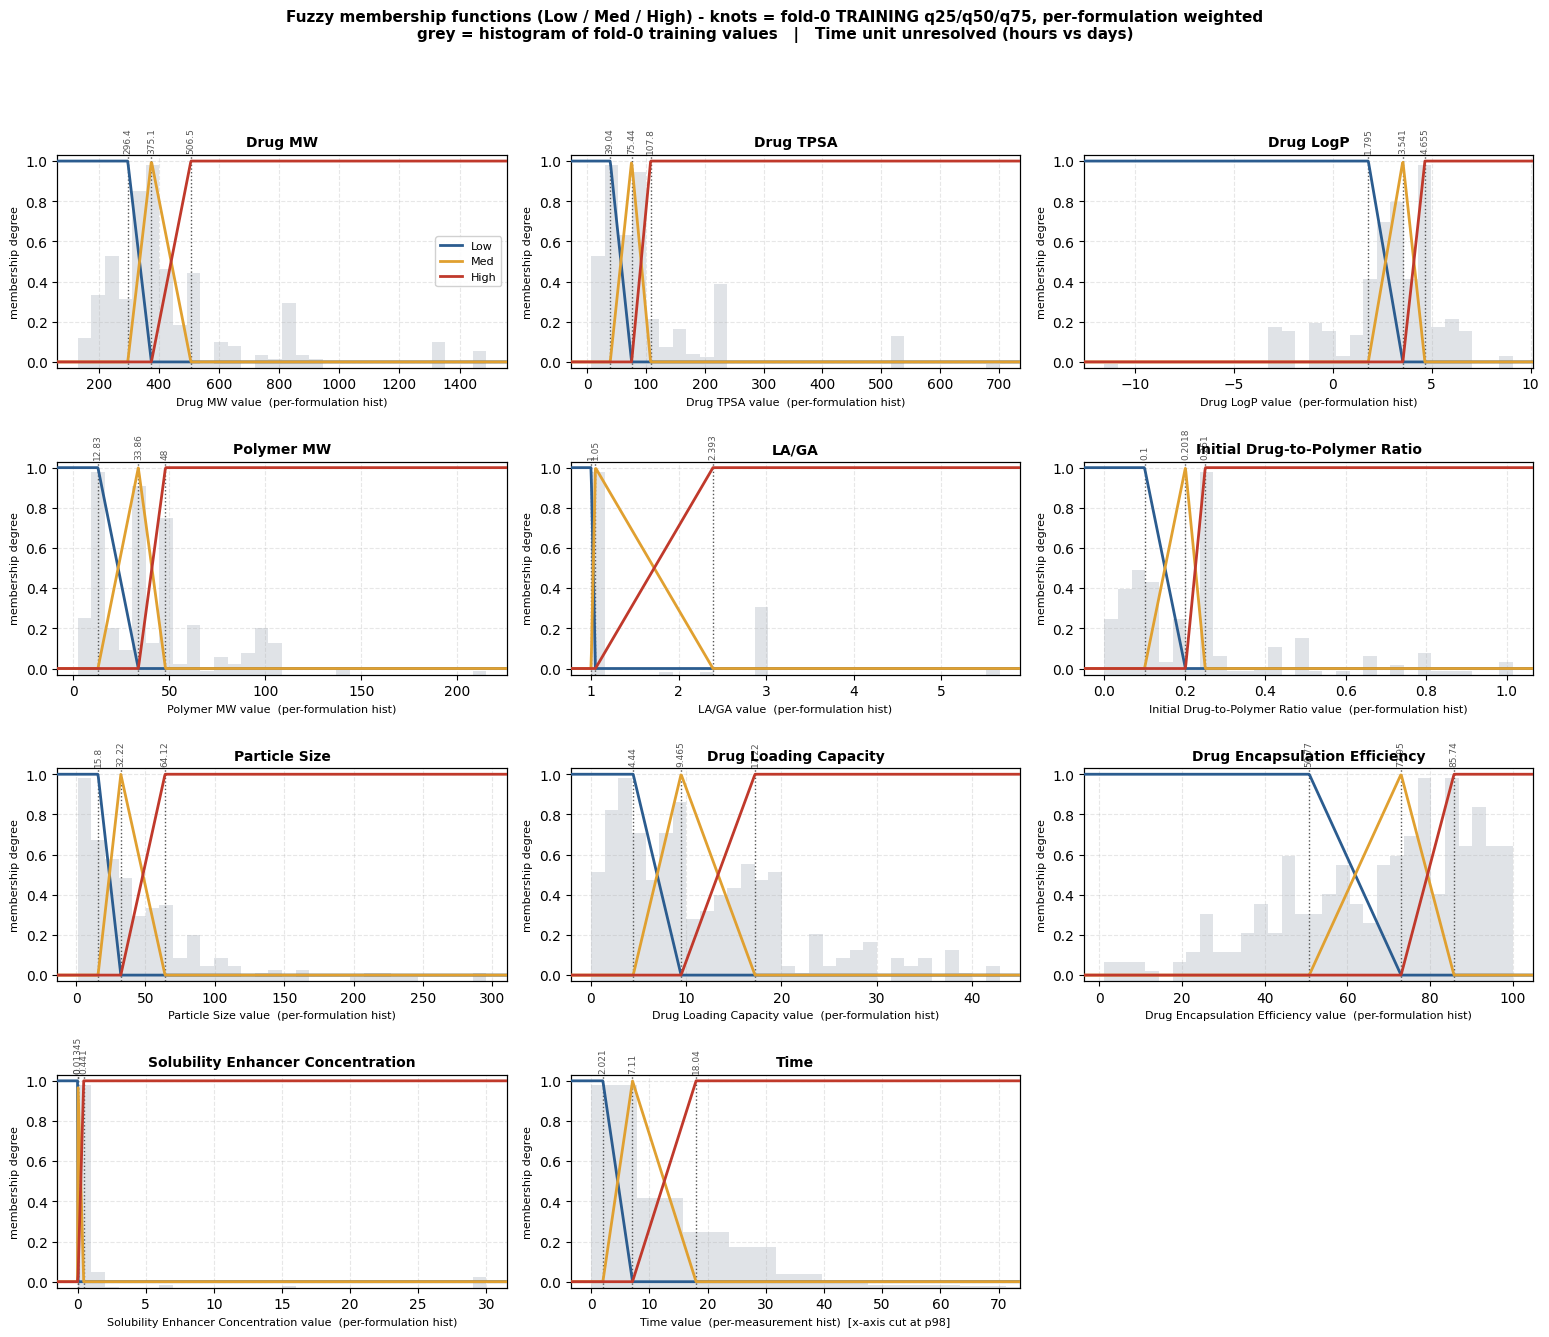

In [11]:
COL = {"Low": "#2b5c8f", "Med": "#e0a030", "High": "#c0392b"}

def plot_feature(ax, feat, knots, train_frame, crisp=None):
    a, b, c = knots
    # plotting range: the training data's range, padded
    if const_in_form[feat]:
        vals = train_frame.drop_duplicates("Formulation Index")[feat].to_numpy(dtype=float)
        hist_note = "per-formulation"
    else:
        vals = train_frame[feat].to_numpy(dtype=float)
        hist_note = "per-measurement"
    lo_x, hi_x = float(np.min(vals)), float(np.max(vals))
    # heavily right-skewed features (Time, Particle Size) are unreadable on their full
    # range, so truncate the VIEW at the 98th percentile. The memberships themselves are
    # unchanged - Low/High are shouldered, so they simply stay flat beyond the cut.
    # نقصّ محور الرسم فقط للوضوح، أما الدوال فلا تتغير.
    q98 = float(np.quantile(vals, 0.98))
    truncated = hi_x > 3 * q98 and q98 > lo_x
    if truncated:
        hi_x = q98
    if crisp:
        lo_x, hi_x = min(lo_x, min(crisp)), max(hi_x, max(crisp))
    pad = 0.05 * (hi_x - lo_x) if hi_x > lo_x else 1.0
    grid = np.linspace(lo_x - pad, hi_x + pad, 800)

    # histogram of the training values, behind the curves
    ax2 = ax.twinx()
    ax2.hist(vals, bins=30, color="#9aa5b1", alpha=0.30, zorder=0)
    ax2.set_yticks([])
    ax2.set_ylabel("")

    L, M, H = triangular_memberships(grid, knots)
    for lab, y in (("Low", L), ("Med", M), ("High", H)):
        ax.plot(grid, y, lw=2.0, color=COL[lab], label=lab, zorder=3)

    for name, v in (("a=q25", a), ("b=q50", b), ("c=q75", c)):
        ax.axvline(v, color="#555555", ls=":", lw=1.0, zorder=2)
        ax.text(v, 1.04, f"{v:.4g}", rotation=90, fontsize=6.5,
                ha="center", va="bottom", color="#555555")

    if crisp:
        # stagger the labels so close-together thresholds stay legible
        for i, t in enumerate(sorted(crisp)):
            ax.axvline(t, color="#111111", ls="--", lw=1.6, zorder=4)
            ax.text(t, 0.92 - 0.17 * (i % 5), f"{t:g}", rotation=90, fontsize=7.5,
                    ha="right", va="top", color="#111111", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.75),
                    zorder=5)

    ax.set_ylim(-0.03, 1.03)
    ax.set_xlim(grid[0], grid[-1])
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.set_title(f"{feat}", fontsize=10, fontweight="bold")
    trunc_note = "  [x-axis cut at p98]" if truncated else ""
    ax.set_xlabel(f"{feat} value  ({hist_note} hist){trunc_note}", fontsize=8)
    ax.set_ylabel("membership degree", fontsize=8)
    ax.grid(True, ls="--", alpha=0.3)

ncol = 3
nrow = int(np.ceil(len(FEATURES) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 3.4 * nrow))
axes = np.atleast_1d(axes).flatten()
for i, feat in enumerate(FEATURES):
    plot_feature(axes[i], feat, KNOTS_F0[feat], train0)
for j in range(len(FEATURES), len(axes)):
    axes[j].axis("off")
axes[0].legend(loc="center right", fontsize=8, framealpha=0.9)
fig.suptitle("Fuzzy membership functions (Low / Med / High) - knots = fold-0 TRAINING q25/q50/q75, "
             "per-formulation weighted\ngrey = histogram of fold-0 training values   |   "
             "Time unit unresolved (hours vs days)",
             fontsize=11, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("membership_functions.png", dpi=160, bbox_inches="tight")
print("Saved membership_functions.png")
plt.show()

### Figure 2 — the collaborator's four features, crisp thresholds overlaid

Black dashed lines are the tree's actual thresholds. Where a black line falls on the
plot tells you immediately which fuzzy label the crisp rule corresponds to — and,
for `Time`, how much of the tree's structure is packed into the far left of the range.

Saved collaborator_rules_fuzzy.png


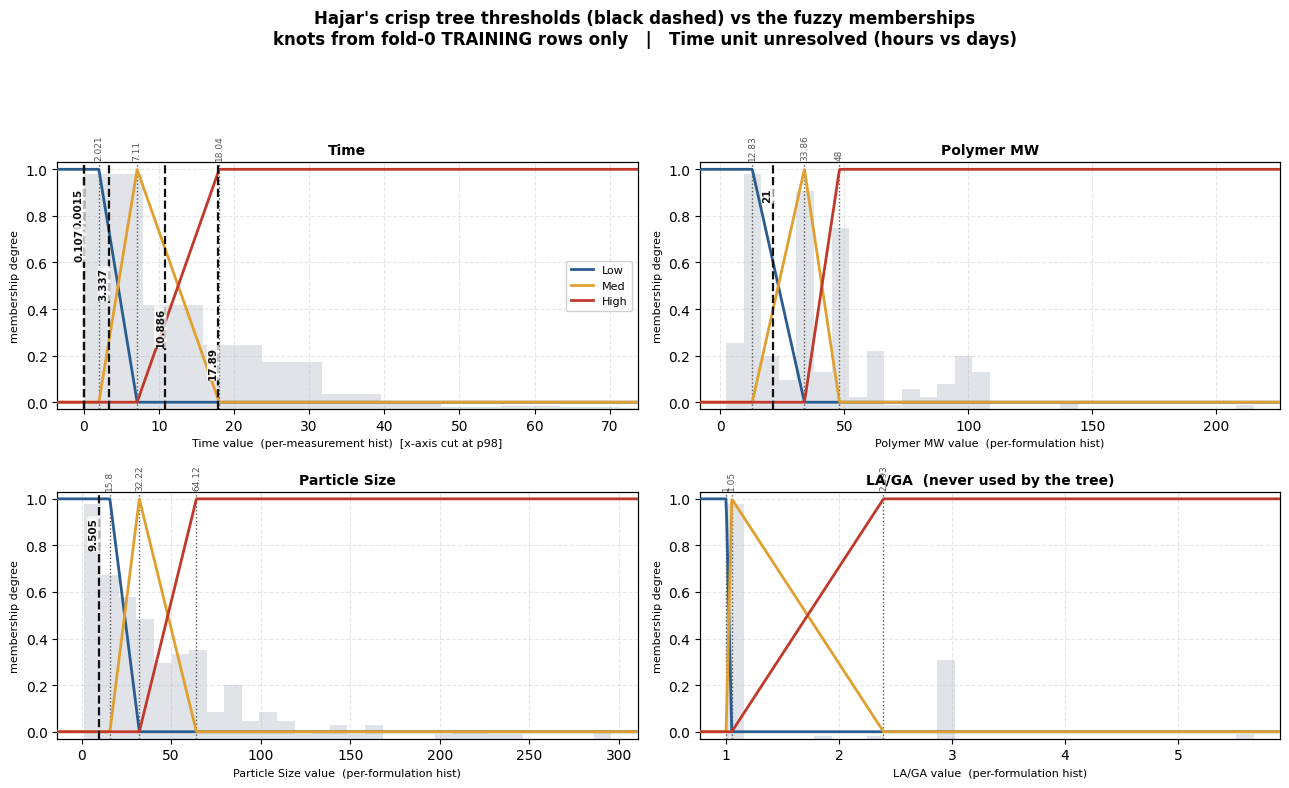

In [12]:
crisp_by_feature = {
    "Time": [0.0015, 0.107, 3.337, 10.886, 17.890],
    "Polymer MW": [21.0],
    "Particle Size": [9.505],
    "LA/GA": [],          # never selected by the tree
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
for i, feat in enumerate(RULE_FEATURES):
    plot_feature(axes[i], feat, KNOTS_F0[feat], train0, crisp=crisp_by_feature[feat] or None)
    if not crisp_by_feature[feat]:
        axes[i].set_title(f"{feat}  (never used by the tree)", fontsize=10, fontweight="bold")
axes[0].legend(loc="center right", fontsize=8, framealpha=0.9)
fig.suptitle("the collaborator's crisp tree thresholds (black dashed) vs the fuzzy memberships\n"
             "knots from fold-0 TRAINING rows only   |   Time unit unresolved (hours vs days)",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.91])
fig.savefig("collaborator_rules_fuzzy.png", dpi=160, bbox_inches="tight")
print("Saved collaborator_rules_fuzzy.png")
plt.show()

Two things the figures make obvious, and that were invisible in the printed rules:

* **`Time` is extremely right-skewed.** Four of the tree's five `Time` splits sit in the
  leftmost sliver of the range. The tree is spending most of its depth resolving the
  early part of the release curve.
* **`Solubility Enhancer Concentration` is near-degenerate, and `LA/GA` nearly so.**
  Each is dominated by one repeated value (`0.0` and `1.0`), so their $a \to b$ knot gap
  collapses: **0.04%** of the feature range for `Solubility Enhancer Concentration` (the
  only feature that trips the 1% flag in 4e-bis) and **1.06%** for `LA/GA` — the two
  thinnest by a wide margin, against 5–22% for every other feature. Their "Medium"
  triangle is effectively a spike. The *exact*-tie fallback never had to fire, but the
  underlying degeneracy is real and plainly visible in the plots. A two-level or
  categorical treatment may be more honest for these two than Low/Med/High. Flagging,
  not fixing — that is a modelling decision to make together.

---
## Task 6 — LEAKAGE SELF-CHECK (must pass)

This is the proof section. Each check prints **PASS** or **FAIL**, and any failure
raises at the end of the cell — so a leaky notebook cannot be silently committed with
green-looking output.

**قسم الإثبات:** كل فحص يطبع نجاح أو فشل، وأي فشل يوقف الدفتر بخطأ.

| Check | What it proves |
|---|---|
| 1 | No SMILES in more than one validation fold — drug grouping holds |
| 2 | No SMILES in both train and validation of the same fold |
| 3 | Fold-k knots came from fold-k **train** rows: recomputing on **val** rows gives *different* numbers, so val was demonstrably not used |
| 4 | Row counts preserved end to end — nothing dropped silently |
| 5 | `Release` never clipped — the max still exceeds 1.0 |
| 6 | Identifiers (`Drug`, `Drug SMILES`) never entered the feature matrix |
| 7 | Memberships stay in [0,1] and sum to 1 on the **validation** fold too |

In [13]:
results = []
def check(name, ok, detail=""):
    results.append((name, bool(ok), detail))
    print(f"[{'PASS' if ok else 'FAIL'}]  {name}")
    if detail:
        print(f"         {detail}")

# --- 1: no SMILES in >1 validation fold ------------------------------------
maxapp = max(len(v) for v in appearances.values())
check("1. No SMILES appears in more than one validation fold",
      maxapp == 1, f"max validation-fold appearances over {len(appearances)} SMILES = {maxapp}")

# --- 2: no SMILES in both train and val of the same fold -------------------
overlaps = []
for k, (tr, va) in enumerate(FOLDS):
    ov = set(df.iloc[tr]["Drug SMILES"]) & set(df.iloc[va]["Drug SMILES"])
    overlaps.append(len(ov))
check("2. No SMILES in both train and validation of the same fold",
      all(o == 0 for o in overlaps), f"per-fold overlap counts = {overlaps}")

# --- 3: knots are train-only (recomputing on val gives different numbers) ---
diff_report, all_features_differ = [], True
for k, (tr, va) in enumerate(FOLDS):
    kn_tr = knots_per_fold[k]
    kn_va, _ = compute_knots(df.iloc[va], FEATURES, verbose=False)
    n_diff = sum(1 for f in FEATURES if not np.allclose(kn_tr[f], kn_va[f], rtol=1e-9, atol=1e-12))
    diff_report.append(f"fold {k}: {n_diff}/{len(FEATURES)} features differ")
    if n_diff == 0:
        all_features_differ = False
check("3. Fold-k knots were computed from fold-k TRAIN rows only",
      all_features_differ,
      "val-recomputed knots differ from the stored train knots -> "
      "validation rows demonstrably did not contribute | " + "; ".join(diff_report))

# show one concrete example so the claim is inspectable, not just asserted
_ex = "Particle Size"
_kv, _ = compute_knots(df.iloc[FOLDS[0][1]], [_ex], verbose=False)
print(f"\n         example - '{_ex}' fold 0:")
print(f"           knots we USED (from TRAIN): {tuple(round(v, 4) for v in knots_per_fold[0][_ex])}")
print(f"           knots if we had used VAL  : {tuple(round(v, 4) for v in _kv[_ex])}   <- never used\n")

# --- 4: nothing dropped -----------------------------------------------------
rows_ok = (len(df) == n_before == 4913) and (sum(len(v) for _, v in FOLDS) == len(df))
check("4. Row counts preserved (nothing dropped silently)",
      rows_ok, f"loaded={n_before}, working={len(df)}, sum(val folds)={sum(len(v) for _, v in FOLDS)}")

# --- 5: Release never clipped ----------------------------------------------
raw_max = pd.read_excel(PROCESSED_PATH)["Release"].max()
check("5. Release was never clipped",
      np.isclose(df["Release"].max(), raw_max) and df["Release"].max() > 1.0,
      f"max(Release) in the notebook = {df['Release'].max():.6f}  |  max in the raw file = {raw_max:.6f}"
      f"  |  {(df['Release'] > 1).sum()} rows exceed 1.0 and were kept")

# --- 6: identifiers never used as features ---------------------------------
leaked = [c for c in ("Drug", "Drug SMILES", "Formulation Index") if c in FEATURES]
check("6. Identifiers never entered the feature matrix",
      not leaked, f"FEATURES = {FEATURES}")

# --- 7: memberships valid on the validation fold ---------------------------
v = memb_val0.to_numpy()
sums_ok = all(np.allclose(memb_val0[[f + '_Low', f + '_Med', f + '_High']].sum(axis=1), 1.0) for f in FEATURES)
check("7. Validation memberships in [0,1] and summing to 1",
      v.min() >= -1e-12 and v.max() <= 1 + 1e-12 and sums_ok,
      f"min={v.min():.6f} max={v.max():.6f} partition-of-unity={sums_ok}")

# --- verdict ----------------------------------------------------------------
print("\n" + "=" * 66)
failed = [n for n, ok, _ in results if not ok]
if failed:
    print("LEAKAGE SELF-CHECK FAILED:", failed)
    raise AssertionError(f"Leakage self-check failed: {failed}")
print(f"ALL {len(results)} LEAKAGE CHECKS PASSED - this notebook is leakage-free by construction.")
print("=" * 66)

[PASS]  1. No SMILES appears in more than one validation fold
         max validation-fold appearances over 88 SMILES = 1
[PASS]  2. No SMILES in both train and validation of the same fold
         per-fold overlap counts = [0, 0, 0, 0, 0]
[PASS]  3. Fold-k knots were computed from fold-k TRAIN rows only
         val-recomputed knots differ from the stored train knots -> validation rows demonstrably did not contribute | fold 0: 11/11 features differ; fold 1: 11/11 features differ; fold 2: 11/11 features differ; fold 3: 11/11 features differ; fold 4: 11/11 features differ

         example - 'Particle Size' fold 0:
           knots we USED (from TRAIN): (15.7974, 32.225, 64.125)
           knots if we had used VAL  : (28.935, 35.4, 44.2525)   <- never used

[PASS]  4. Row counts preserved (nothing dropped silently)
         loaded=4913, working=4913, sum(val folds)=4913


[PASS]  5. Release was never clipped
         max(Release) in the notebook = 1.081614  |  max in the raw file = 1.081614  |  108 rows exceed 1.0 and were kept
[PASS]  6. Identifiers never entered the feature matrix
         FEATURES = ['Drug MW', 'Drug TPSA', 'Drug LogP', 'Polymer MW', 'LA/GA', 'Initial Drug-to-Polymer Ratio', 'Particle Size', 'Drug Loading Capacity', 'Drug Encapsulation Efficiency', 'Solubility Enhancer Concentration', 'Time']
[PASS]  7. Validation memberships in [0,1] and summing to 1
         min=0.000000 max=1.000000 partition-of-unity=True

ALL 7 LEAKAGE CHECKS PASSED - this notebook is leakage-free by construction.


---
## Task 7 — Summary and the honest next step

### What was built

* The collaborator's 8-rule tree **reproduced** (Task 2) and clearly labelled as exploratory and
  full-data-fitted — not a result. Its 7 thresholds are the input to the fuzzification,
  and we confirmed her `Release.clip(0,1)` changed none of them.
* A **grouped split** on exact `Drug SMILES`, `GroupKFold(5)`, with printed proof of
  zero drug overlap across validation folds (Task 3).
* **Triangular Low / Med / High memberships** for all 11 numeric features, with knots at
  q25/q50/q75 computed from **training rows only** and with each **formulation weighted
  equally** rather than each measurement (Task 4). An explicit, printed tie-fallback
  ladder guards `LA/GA` and `Solubility Enhancer Concentration`; on this data it never
  needed to fire (collapsing repeated values before interpolating avoids the exact tie),
  but both features are measurably near-degenerate — knot gaps of 1.06% and 0.04% of
  range against 5–22% elsewhere (Task 4e-bis).
* **Figures**: `membership_functions.png` (all features, with training histograms) and
  `collaborator_rules_fuzzy.png` (the collaborator's four features with the crisp thresholds overlaid).
* **`membership_knots.csv`** — every knot for every feature for all 5 folds, so the
  memberships are reproducible without re-running anything.
* A **leakage self-check** (Task 6) that raises rather than warns.

### What is true about these memberships

They are **train-fold-only objects**. The knots in `membership_knots.csv` differ per
fold, and that is the point — fold *k*'s memberships are a function of fold *k*'s
training drugs and nothing else. Any model trained downstream must recompute knots
inside its own fold loop; reusing fold 0's knots across all folds would reintroduce the
leak we just removed.

### The honest next step

1. **Train models on these memberships under the same grouped split** — the membership
   columns from Task 4f become the design matrix, fitted per fold with per-fold knots.
2. **Test whether the collaborator's rule thresholds survive as fuzzy rules.** The prior finding
   from the earlier audit is directly relevant and should be stated up front rather than
   rediscovered: **time-dominated rules tend not to survive a time-window control.**
   Five of the tree's seven splits are on `Time`, so a large part of what those 8 rules
   "explain" is simply that cumulative release rises with time. The correct control is
   to compare within a fixed time window (or include `Time` in the baseline and ask what
   the formulation features add on top of it). Until that control is run, we should not
   claim the rules describe formulation effects.
3. **Settle the `Time` unit** with the data source. Hours vs days is still unresolved. It
   does not change any membership function, but it changes every sentence we would write
   about a rule.
4. **Reconsider the Low/Med/High scheme for the two near-degenerate features.**
   `LA/GA` and `Solubility Enhancer Concentration` are dominated by a single repeated
   value; a three-way fuzzy partition may be more structure than the data supports.
5. **Note that two of the collaborator's five `Time` thresholds are fuzzily indistinguishable**
   (both saturate at Low 1.00). Any fuzzy rule base built from these 8 rules should
   start from roughly three `Time` antecedents, not five.

### What this notebook does **not** claim

No predictive performance is reported here, because none was measured. Nothing in this
notebook is evidence that the fuzzy rules are better, or even as good, as the crisp
ones — only that they are now built without leakage, so that such a comparison can
finally be made honestly.

**الخلاصة:** بنينا دوال العضوية من بيانات التدريب فقط، وأثبتنا خلوّها من التسريب. الخطوة
التالية هي تدريب النماذج بنفس التقسيم، واختبار هل تصمد قواعد المتعاون بعد ضبط عامل الزمن.